In [1]:
from nltk.tokenize import word_tokenize

# test_text = """
#     The quick brown fox jumps over the lazy dog. This is a very common pangram
#     that has been used for testing typewriters and computer keyboards because it
#     contains every single letter of the alphabet. It has been in use since at
#     least the late 1800s and it remains popular today in the modern era.
#     """


test_text = """You are a helpful assistant. Be concise and answer in clear, complete sentences.

    Climate change is one of the most pressing issues facing humanity today. The scientific consensus is clear:
    global temperatures are rising at an unprecedented rate, primarily due to human activities such as burning
    fossil fuels, deforestation, and industrial processes. The Intergovernmental Panel on Climate Change (IPCC)
    has documented extensive evidence showing that the average global temperature has increased by approximately
    1.1°C since the pre-industrial era. This warming trend has led to numerous observable effects, including
    melting polar ice caps, rising sea levels, more frequent and severe weather events, and shifts in wildlife
    populations and habitats.

    The impacts of climate change are far-reaching and affect every aspect of human society and natural ecosystems.
    Coastal communities face increased flooding risks, agricultural systems are disrupted by changing precipitation
    patterns, and extreme weather events cause billions of dollars in damage annually. Scientists warn that without
    significant action to reduce greenhouse gas emissions, these effects will intensify, potentially leading to
    catastrophic consequences for future generations.

    Addressing climate change requires a multifaceted approach involving governments, businesses, and individuals.
    Transitioning to renewable energy sources, improving energy efficiency, protecting and restoring forests, and
    developing sustainable agricultural practices are all crucial steps. International cooperation, as exemplified
    by agreements like the Paris Climate Accord, plays a vital role in coordinating global efforts to limit.
    
    What is the main conclusion of this article in under 100 words?"""

In [2]:
## Caveman Compressor
# This will be our simple baseline compression method which removes certain unnecessary words from the prompt.

import re

stopwords = {
    # Articles
    'a', 'an', 'the',
    # Auxiliary verbs
    'is', 'are', 'was', 'were', 'am', 'be', 'been', 'being',
    'has', 'have', 'had', 'having',
    'do', 'does', 'did', 'doing',
    'will', 'would', 'shall', 'should', 'may', 'might', 'must', 'can', 'could',
    # Common but often non-essential words
    'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into',
    'through', 'during', 'before', 'after', 'above', 'below', 'from',
    'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again',
    'further', 'then', 'once',
    # Pronouns (keeping some key ones, removing others)
    'this', 'that', 'these', 'those',
    # Other
    'there', 'here', 'where',
    'very', 'just', 'really', 'quite', 'too', 'so',
}
#TODO: can we change this for a library of stop words?

def caveman_compressor(text: str, stopwords: set) -> str:
    """
    Compress text by removing stopwords.
    Preserves sentence structure but creates "caveman" style English.
    """
    # Split into sentences, capturing punctuation
    sentences = re.split(r'([.!?]+)', text)
    
    compressed_sentences = []
    for i in range(0, len(sentences), 2):
        sentence = sentences[i].strip()
        punctuation = sentences[i + 1] if i + 1 < len(sentences) else ''

        # Filter out stopwords
        filtered_words = [
            word for word in sentence.split()
            if re.sub(r'[^\w\']', '', word.lower()) not in stopwords
        ]
        
        if filtered_words:
            compressed_sentences.append(' '.join(filtered_words) + punctuation)
    
    result = ' '.join(compressed_sentences).strip()
    
    # Clean up spacing around punctuation
    result = re.sub(r'\s+([.!?,;:])', r'\1', result)
    result = re.sub(r'\s+', ' ', result)
    
    return result

In [3]:
compressed_text = caveman_compressor(test_text, stopwords)
print(compressed_text)
print()
print(f"Original length (tokens): {len(word_tokenize(test_text.lower()))}")
print(f"Compressed length (tokens): {len(word_tokenize(compressed_text.lower()))}") 

You helpful assistant. concise and answer clear, complete sentences. Climate change one most pressing issues facing humanity today. scientific consensus clear: global temperatures rising unprecedented rate, primarily due to human activities such as burning fossil fuels, deforestation, and industrial processes. Intergovernmental Panel Climate Change (IPCC) documented extensive evidence showing average global temperature increased approximately 1. 1°C since pre-industrial era. warming trend led to numerous observable effects, including melting polar ice caps, rising sea levels, more frequent and severe weather events, and shifts wildlife populations and habitats. impacts climate change far-reaching and affect every aspect human society and natural ecosystems. Coastal communities face increased flooding risks, agricultural systems disrupted changing precipitation patterns, and extreme weather events cause billions dollars damage annually. Scientists warn without significant action to redu

In [4]:
## LLM-Lingua2 Compressor
# This will be our advanced compression method using an LLM to intelligently shorten the prompt while preserving

from llmlingua import PromptCompressor
import torch

# Detect and use the best available backend
if torch.backends.mps.is_available():
    backend = "mps"
    print("Initializing LLMLingua-2 compressor (using MPS - Apple Silicon GPU)...")
elif torch.cuda.is_available():
    backend = "cuda"
    print("Initializing LLMLingua-2 compressor (using CUDA)...")
else:
    backend = "cpu"
    print("Initializing LLMLingua-2 compressor (using CPU)...")

LLMlingua_compressor = PromptCompressor(
    model_name="microsoft/llmlingua-2-bert-base-multilingual-cased-meetingbank",
    use_llmlingua2=True,
    device_map=backend,
        )

def LLMlingua_compress(text: str,  rate: float = 0.5, compressor = LLMlingua_compressor) -> str:
    """
    Compress text using LLMLingua-2. 

    Returns:
        Compressed text
    """
    # LLMLingua-2 expects text as a list of strings or single string
    # Only pass target_token if it's set, otherwise use rate

    compress_kwargs = {
        # 'force_tokens': ['\n', '?', '!', '.'],  # Preserve important punctuation
        'use_sentence_level_filter': True,
        'use_context_level_filter': True,
        'use_token_level_filter': True,
        'rate': rate
    }

    result = compressor.compress_prompt(text, **compress_kwargs)

    return result['compressed_prompt']


/Users/adamfletcher/Documents/GitHub/LLM-prompt_compression/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Initializing LLMLingua-2 compressor (using MPS - Apple Silicon GPU)...


`torch_dtype` is deprecated! Use `dtype` instead!


In [5]:
compressed_text = LLMlingua_compress(text= test_text
                   , rate=0.5)

print(compressed_text)
print()
print(f"Original length (tokens): {len(word_tokenize(test_text.lower()))}")
print(f"Compressed length (tokens): {len(word_tokenize(compressed_text.lower()))}") 

helpful assistant concise answer complete sentences Climate change pressing. scientific consensus global temperatures rising unprecedented due to human activities fossil fuels deforestation industrial processes. Intergovernmental Panel on Climate Change documented average global temperature increased 1. 1°C since pre - industrial era warming trend led effects ice caps rising sea levels weather events shifts wildlife populations habitats impacts affect society ecosystems Coastal communities face flooding risks agricultural systems disrupted extreme weather events cause billions damage annually without greenhouse gas emissions effects intensify catastrophic consequences multifaceted approach governments businesses Transitioning renewable energy sources energy efficiency protecting restoring forests sustainable agricultural practices crucial International cooperation Paris Climate Accord global efforts limit main conclusion under 100 words

Original length (tokens): 274
Compressed length 

In [6]:
##Sending Prompts to LLM

from dotenv import load_dotenv
from openai import OpenAI
import os
import tiktoken

load_dotenv()
model = "gpt-4"

api_key = os.getenv("OPENAI_API_KEY")
client = OpenAI(api_key=api_key)
encoding = tiktoken.encoding_for_model(model)


# prompt = """
# Summarize the following text: The quick brown fox jumps over the lazy dog. This is a common pangram used to test typewriters and computer keyboards because it contains every letter of the alphabet. It has been used since at least the late 1800s and remains popular today."
# """

prompt = test_text

def send_prompt(client, prompt: str, **kwargs):
    """Send prompt to OpenAI and return response with token counts."""
    response = client.chat.completions.create(
        model= model,
        messages=[{"role": "user", "content": prompt}],
        **kwargs
    )
    return response.choices[0].message.content


def demo_end_to_end(client, prompt: str):
    """Demonstrate end-to-end compression + LLM."""
    print("\n" + "="*80)
    print("END-TO-END DEMO: COMPRESSION + LLM")
    print("="*80)


    print(f"\nOriginal prompt ({len(word_tokenize(prompt.lower()))} Tokens):")
    print(prompt)

    # Compress with caveman
    print("\n" + "-"*80)
    print("CAVEMAN COMPRESSION")
    print("-"*80)
    caveman_compressed = caveman_compressor(prompt, stopwords)

    print(f"Caveman compressed ({len(word_tokenize(caveman_compressed.lower()))} Tokens):")
    print(caveman_compressed)

    # Compress with LLMLingua-2
    print("\n" + "-"*80)
    print("LLMLINGUA-2 COMPRESSION")
    print("-"*80)

    llmlingua_compressed = LLMlingua_compress(prompt, rate=0.7)

    print(f"LLMLingua-2 compressed ({len(word_tokenize(llmlingua_compressed.lower()))} Tokens):")
    print(llmlingua_compressed)


    # Send to LLM
    print("\n" + "-"*80)
    print("SENDING TO LLM")
    print("-"*80)

    print("\n--- Original prompt ---")
    response1 = send_prompt(client, prompt)
    print(f"Output: {response1}")
    print(f"Tokens used: {len(word_tokenize(response1.lower()))}")

    print("\n--- Caveman compressed prompt ---")
    response2 = send_prompt(client, caveman_compressed)
    print(f"Output: {response2}")
    print(f"Tokens used: {len(word_tokenize(response2.lower()))}")

    print("\n--- LLMLingua-2 compressed prompt ---")
    response3 = send_prompt(client, llmlingua_compressed)

    print(f"Output: {response3}")
    print(f"Tokens used: {len(word_tokenize(response3.lower()))}")


In [7]:
demo_end_to_end(client, prompt)


END-TO-END DEMO: COMPRESSION + LLM

Original prompt (274 Tokens):
You are a helpful assistant. Be concise and answer in clear, complete sentences.

    Climate change is one of the most pressing issues facing humanity today. The scientific consensus is clear:
    global temperatures are rising at an unprecedented rate, primarily due to human activities such as burning
    fossil fuels, deforestation, and industrial processes. The Intergovernmental Panel on Climate Change (IPCC)
    has documented extensive evidence showing that the average global temperature has increased by approximately
    1.1°C since the pre-industrial era. This warming trend has led to numerous observable effects, including
    melting polar ice caps, rising sea levels, more frequent and severe weather events, and shifts in wildlife
    populations and habitats.

    The impacts of climate change are far-reaching and affect every aspect of human society and natural ecosystems.
    Coastal communities face increas

In [8]:
## Oreo Method: Compress the middle bit around some key start and end instructions

prompt = {
    'system_instructions': "You are a helpful assistant. Be concise and answer in clear, complete sentences.",
    'content': """
    Climate change is one of the most pressing issues facing humanity today. The scientific consensus is clear:
    global temperatures are rising at an unprecedented rate, primarily due to human activities such as burning
    fossil fuels, deforestation, and industrial processes. The Intergovernmental Panel on Climate Change (IPCC)
    has documented extensive evidence showing that the average global temperature has increased by approximately
    1.1°C since the pre-industrial era. This warming trend has led to numerous observable effects, including
    melting polar ice caps, rising sea levels, more frequent and severe weather events, and shifts in wildlife
    populations and habitats.

    The impacts of climate change are far-reaching and affect every aspect of human society and natural ecosystems.
    Coastal communities face increased flooding risks, agricultural systems are disrupted by changing precipitation
    patterns, and extreme weather events cause billions of dollars in damage annually. Scientists warn that without
    significant action to reduce greenhouse gas emissions, these effects will intensify, potentially leading to
    catastrophic consequences for future generations.

    Addressing climate change requires a multifaceted approach involving governments, businesses, and individuals.
    Transitioning to renewable energy sources, improving energy efficiency, protecting and restoring forests, and
    developing sustainable agricultural practices are all crucial steps. International cooperation, as exemplified
    by agreements like the Paris Climate Accord, plays a vital role in coordinating global efforts to limit
    temperature increases and adapt to unavoidable changes.
    """,
    'query': "What is the main conclusion of this article in under 100 words?"}



def oreo_demo(client, prompt: str):
    """Demonstrate end-to-end compression + LLM."""
    print("\n" + "="*80)
    print("OREO DEMO: COMPRESSION + LLM")
    print("="*80)

    original_prompt = prompt["system_instructions"] + "\n" + prompt["content"] + "\n" + prompt["query"]
    print(original_prompt)
    print(f"\nOriginal prompt ({len(word_tokenize(original_prompt.lower()))} Tokens):")

    # Compress with caveman
    print("\n" + "-"*80)
    print("CAVEMAN COMPRESSION")
    print("-"*80)
    caveman_compressed = caveman_compressor(prompt["content"], stopwords)
    oreo_caveman_prompt = prompt["system_instructions"] + "\n" + caveman_compressed + "\n" + prompt["query"]

    print(f"Caveman compressed ({len(word_tokenize(caveman_compressed.lower()))} Tokens):")
    print(oreo_caveman_prompt)

    # Compress with LLMLingua-2
    print("\n" + "-"*80)
    print("LLMLINGUA-2 COMPRESSION")
    print("-"*80)

    llmlingua_compressed = LLMlingua_compress(prompt["content"], rate=0.5)
    oreo_llmlingua_prompt = prompt["system_instructions"] + "\n" + llmlingua_compressed + "\n" + prompt["query"]

    print(f"LLMLingua-2 compressed ({len(word_tokenize(llmlingua_compressed.lower()))} Tokens):")
    print(oreo_llmlingua_prompt)


    # Send to LLM
    print("\n" + "-"*80)
    print("SENDING TO LLM")
    print("-"*80)

    print("\n--- Original prompt ---")
    response1 = send_prompt(client, original_prompt)
    print(f"Output: {response1}")
    print(f"Tokens used: {len(word_tokenize(response1.lower()))}")

    print("\n--- Caveman compressed prompt ---")
    response2 = send_prompt(client, oreo_caveman_prompt)
    print(f"Output: {response2}")
    print(f"Tokens used: {len(word_tokenize(response2.lower()))}")

    print("\n--- LLMLingua-2 compressed prompt ---")
    response3 = send_prompt(client, oreo_llmlingua_prompt)
    print(f"Output: {response3}")
    print(f"Tokens used: {len(word_tokenize(response3.lower()))}")

In [9]:
oreo_demo(client, prompt)


OREO DEMO: COMPRESSION + LLM
You are a helpful assistant. Be concise and answer in clear, complete sentences.

    Climate change is one of the most pressing issues facing humanity today. The scientific consensus is clear:
    global temperatures are rising at an unprecedented rate, primarily due to human activities such as burning
    fossil fuels, deforestation, and industrial processes. The Intergovernmental Panel on Climate Change (IPCC)
    has documented extensive evidence showing that the average global temperature has increased by approximately
    1.1°C since the pre-industrial era. This warming trend has led to numerous observable effects, including
    melting polar ice caps, rising sea levels, more frequent and severe weather events, and shifts in wildlife
    populations and habitats.

    The impacts of climate change are far-reaching and affect every aspect of human society and natural ecosystems.
    Coastal communities face increased flooding risks, agricultural syste

In [10]:
## The combination of using A compressor with the Oreo method PLUS an output response length seems to give the best results overall.

# But, it means that it's use it more specific to general purpose. 

create blank dataframe

for prompt in prompts:
    for compression_method in compression_methods:
        for normalprompt vs oreoprompt
            compress the input prompt
            send to LLM
            for metric in quality_metrics:
                run output against metric
                add each element to a dataframe



In [ ]:
prompts = [
    {
    'system_instructions': "You are a helpful assistant. Be concise and answer in clear, complete sentences.",
    'content': """
    Climate change is one of the most pressing issues facing humanity today. The scientific consensus is clear:
    global temperatures are rising at an unprecedented rate, primarily due to human activities such as burning
    fossil fuels, deforestation, and industrial processes. The Intergovernmental Panel on Climate Change (IPCC)
    has documented extensive evidence showing that the average global temperature has increased by approximately
    1.1°C since the pre-industrial era. This warming trend has led to numerous observable effects, including
    melting polar ice caps, rising sea levels, more frequent and severe weather events, and shifts in wildlife
    populations and habitats.

    The impacts of climate change are far-reaching and affect every aspect of human society and natural ecosystems.
    Coastal communities face increased flooding risks, agricultural systems are disrupted by changing precipitation
    patterns, and extreme weather events cause billions of dollars in damage annually. Scientists warn that without
    significant action to reduce greenhouse gas emissions, these effects will intensify, potentially leading to
    catastrophic consequences for future generations.

    Addressing climate change requires a multifaceted approach involving governments, businesses, and individuals.
    Transitioning to renewable energy sources, improving energy efficiency, protecting and restoring forests, and
    developing sustainable agricultural practices are all crucial steps. International cooperation, as exemplified
    by agreements like the Paris Climate Accord, plays a vital role in coordinating global efforts to limit
    temperature increases and adapt to unavoidable changes.
    """,
    'query': "What is the main conclusion of this article in under 100 words?"},
    {
    'system_instructions': "You are a review analyzer. Extract the key sentiment and main points. Be concise.",
    'content': """
    I recently purchased the UltraWidget Pro 3000 and I have to say, I'm thoroughly impressed with this product.
    Right out of the box, the build quality is exceptional - it feels solid and well-constructed, with attention
    to detail in every aspect. The sleek design fits perfectly in my workspace and the matte black finish looks
    professional and modern.

    In terms of performance, the UltraWidget Pro 3000 exceeds expectations. It handles everything I throw at it
    with ease, from basic tasks to more demanding operations. The battery life is outstanding - I can go a full
    day of heavy use without needing to recharge. The display is crisp and vibrant, making it a pleasure to use
    for extended periods.

    The user interface is intuitive and easy to navigate, even for someone who isn't particularly tech-savvy.
    Setup was a breeze - I had it up and running in less than 10 minutes. The accompanying mobile app works
    flawlessly and adds convenient remote control functionality.

    Customer support has been excellent. When I had a minor question about one of the features, I reached their
    support team via chat and received helpful, detailed assistance within minutes. They clearly stand behind
    their product.

    The only minor drawback I've noticed is that it can get slightly warm during intensive use, but this hasn't
    affected performance at all and is barely noticeable. For the price point, this is an exceptional value.
    I would highly recommend the UltraWidget Pro 3000 to anyone looking for a reliable, high-quality solution.
    """,
    'query': "What is the overall sentiment and key points of this review"
            }
    ]

#TODO: Make about 5 prompts of varying types

In [ ]:
from meteor_scorer import (
    setup_nltk_resources,
    calculate_meteor
)

full_results = []

for prompt in prompts:
    for compression_method in ['Control', 'Caveman', 'LLMLingua-2']:
        for promptstructure in ['Normal', 'Oreo']:

            if promptstructure == 'Normal':
                full_prompt = prompt["system_instructions"] + "\n" + prompt["content"] + "\n" + prompt["query"]
            elif promptstructure == 'Oreo':
                if compression_method == 'Control':
                    full_prompt = prompt["system_instructions"] + "\n" + prompt["content"] + "\n" + prompt["query"]
                elif compression_method == 'Caveman':
                    caveman_compressed = caveman_compressor(prompt["content"], stopwords)
                    full_prompt = prompt["system_instructions"] + "\n" + caveman_compressed + "\n" + prompt["query"]
                elif compression_method == 'LLMLingua-2':
                    llmlingua_compressed = LLMlingua_compress(prompt["content"], rate=0.5)
                    full_prompt = prompt["system_instructions"] + "\n" + llmlingua_compressed + "\n" + prompt["query"]
            
            n_input_tokens = len(word_tokenize(full_prompt.lower()))
            print(f'{compression_method} - {promptstructure} Prompt. ({n_input_tokens} Tokens):')
            #send to LLM
            response = send_prompt(client, full_prompt)
            n_output_tokens = len(word_tokenize(response.lower()))

            result_meteor = calculate_meteor(control_output, compressed_output)
            
            results = {'prompt:': prompt,
                       'compression_method': compression_method,
                       'prompt_structure': promptstructure,
                       'output': response,
                       'n_input_tokens': n_input_tokens,
                       'n_output_tokens': n_output_tokens}
            
            full_results.append(results)

            


Control - Normal Prompt. (281 Tokens):
Control - Oreo Prompt. (281 Tokens):
Caveman - Normal Prompt. (281 Tokens):
Caveman - Oreo Prompt. (246 Tokens):
LLMLingua-2 - Normal Prompt. (281 Tokens):
LLMLingua-2 - Oreo Prompt. (137 Tokens):
Control - Normal Prompt. (311 Tokens):
Control - Oreo Prompt. (311 Tokens):
Caveman - Normal Prompt. (311 Tokens):
Caveman - Oreo Prompt. (249 Tokens):
LLMLingua-2 - Normal Prompt. (311 Tokens):
LLMLingua-2 - Oreo Prompt. (157 Tokens):


In [35]:
def calculate_metrics(control_prompt: str, control_response: str,
                      test_prompt: str, test_response: str,
                      method: str, prompt_structure: str) -> dict:
    """Calculate metrics for compressed prompts and responses compared to control."""
    #Quantitative Metrics (Prompt)
    control_n_input_tokens = len(word_tokenize(control_prompt.lower()))
    test_n_input_tokens = len(word_tokenize(test_prompt.lower()))
    input_compression_ratio = test_n_input_tokens / control_n_input_tokens 

    #Quantitative Metrics (Response)
    control_n_output_tokens = len(word_tokenize(control_response.lower()))
    test_n_output_tokens = len(word_tokenize(test_response.lower()))
    output_compression_ratio = test_n_output_tokens / control_n_output_tokens

    #Quality Metrics (Response)
    meteor_score = calculate_meteor(control_response, test_response)
    bertscore = calculate_bertscore(control_response, test_response)

    #prompt ID:
    prompt_id = ' '.join(test_prompt.split(' ')[:5])

    return [{
        'prompt_id': prompt_id,
        'compression_method': method,
        'prompt_structure': prompt_structure,
        'contol_n_input_tokens': control_n_input_tokens,
        'test_n_input_tokens': test_n_input_tokens,
        'input_compression_ratio': input_compression_ratio,
        'control_n_output_tokens': control_n_output_tokens,
        'test_n_output_tokens': test_n_output_tokens,
        'output_compression_ratio': output_compression_ratio,
        'quality_metric': 'meteor',
        'score': meteor_score['score']},
        {
        'prompt_id': prompt_id,
        'compression_method': method,
        'prompt_structure': prompt_structure,
        'contol_n_input_tokens': control_n_input_tokens,
        'test_n_input_tokens': test_n_input_tokens,
        'input_compression_ratio': input_compression_ratio,
        'control_n_output_tokens': control_n_output_tokens,
        'test_n_output_tokens': test_n_output_tokens,
        'output_compression_ratio': output_compression_ratio,
        'quality_metric': 'bertscore',
        'score': bertscore['score']}
        ]

In [36]:
from meteor_scorer import (
    setup_nltk_resources,
    calculate_meteor
)
from bertscore_scorer import calculate_bertscore


setup_nltk_resources()

full_results = []

for prompt in prompts:
    print(prompt)

    full_prompt = prompt["system_instructions"] + "\n" + prompt["content"] + "\n" + prompt["query"]

    # Control Results
    control_response = send_prompt(client, full_prompt)

    #Compressed Results - Caveman (Non-Oreo)
    normal_caveman_compressed_prompt = caveman_compressor(full_prompt, stopwords)
    normal_caveman_response = send_prompt(client, normal_caveman_compressed_prompt)
    caveman_normal_metrics = calculate_metrics(control_prompt=full_prompt, control_response=control_response, 
                                               test_prompt=normal_caveman_compressed_prompt, test_response=normal_caveman_response,
                                               method='caveman', prompt_structure='normal')
    full_results.extend(caveman_normal_metrics)
    print('caveman normal')

    #Compressed Results - LLMLingua-2 (Non-Oreo)
    normal_llmlingua_compressed_prompt = LLMlingua_compress(full_prompt, rate=0.5)
    normal_llmlingua_response = send_prompt(client, normal_llmlingua_compressed_prompt)
    llmlingua_normal_metrics = calculate_metrics(control_prompt=full_prompt, control_response=control_response, 
                                               test_prompt=normal_llmlingua_compressed_prompt, test_response=normal_llmlingua_response,
                                               method='llmlingua-2', prompt_structure='normal')
    full_results.extend(llmlingua_normal_metrics)
    print('llm lingua normal')


    #Oreo Caveman
    oreo_caveman_compressed_content = caveman_compressor(prompt["content"], stopwords)
    caveman_compressed_prompt = prompt["system_instructions"] + "\n" +  oreo_caveman_compressed_content + "\n" + prompt["query"]
    oreo_caveman_response = send_prompt(client, caveman_compressed_prompt)
    caveman_oreo_metrics = calculate_metrics(control_prompt=full_prompt, control_response=control_response, 
                                               test_prompt=caveman_compressed_prompt, test_response=oreo_caveman_response,
                                               method='caveman', prompt_structure='oreo')
    full_results.extend(caveman_oreo_metrics)
    print('caveman oreo')

    #Oreo LLMLingua-2
    oreo_llmlingua_compressed_content = LLMlingua_compress(prompt["content"], rate=0.5)
    llmlingua_compressed_prompt = prompt["system_instructions"] + "\n" + oreo_llmlingua_compressed_content + "\n" + prompt["query"]
    oreo_llmlingua_response = send_prompt(client, llmlingua_compressed_prompt)
    llmlingua_oreo_metrics = calculate_metrics(control_prompt=full_prompt, control_response=control_response, 
                                               test_prompt=llmlingua_compressed_prompt, test_response=oreo_llmlingua_response,
                                               method='llmlingua-2', prompt_structure='oreo')
    full_results.extend(llmlingua_oreo_metrics)
    print('llm lingua oreo')


    
    


{'system_instructions': 'You are a helpful assistant. Be concise and answer in clear, complete sentences.', 'content': '\n    Climate change is one of the most pressing issues facing humanity today. The scientific consensus is clear:\n    global temperatures are rising at an unprecedented rate, primarily due to human activities such as burning\n    fossil fuels, deforestation, and industrial processes. The Intergovernmental Panel on Climate Change (IPCC)\n    has documented extensive evidence showing that the average global temperature has increased by approximately\n    1.1°C since the pre-industrial era. This warming trend has led to numerous observable effects, including\n    melting polar ice caps, rising sea levels, more frequent and severe weather events, and shifts in wildlife\n    populations and habitats.\n\n    The impacts of climate change are far-reaching and affect every aspect of human society and natural ecosystems.\n    Coastal communities face increased flooding risks,

In [37]:
import pandas as pd

df = pd.DataFrame(full_results)
df

,prompt_id,compression_method,prompt_structure,contol_n_input_tokens,test_n_input_tokens,input_compression_ratio,control_n_output_tokens,test_n_output_tokens,output_compression_ratio,quality_metric,score
0,You helpful assistant. concise and,caveman,normal,281,236,0.839858,93,127,1.365591,meteor,0.574499
1,You helpful assistant. concise and,caveman,normal,281,236,0.839858,93,127,1.365591,bertscore,0.890668
2,helpful assistant concise answer complete,llmlingua-2,normal,281,119,0.423488,93,115,1.236559,meteor,0.397451
3,helpful assistant concise answer complete,llmlingua-2,normal,281,119,0.423488,93,115,1.236559,bertscore,0.845178
4,You are a helpful assistant.,caveman,oreo,281,246,0.875445,93,83,0.892473,meteor,0.399781
5,You are a helpful assistant.,caveman,oreo,281,246,0.875445,93,83,0.892473,bertscore,0.885476
6,You are a helpful assistant.,llmlingua-2,oreo,281,137,0.487544,93,96,1.032258,meteor,0.411308
7,You are a helpful assistant.,llmlingua-2,oreo,281,137,0.487544,93,96,1.032258,bertscore,0.870666
8,You review analyzer. Extract key,caveman,normal,317,245,0.772871,15,18,1.200000,meteor,0.583007
9,You review analyzer. Extract key,caveman,normal,317,245,0.772871,15,18,1.200000,bertscore,0.902956


<Axes: xlabel='compression_method'>

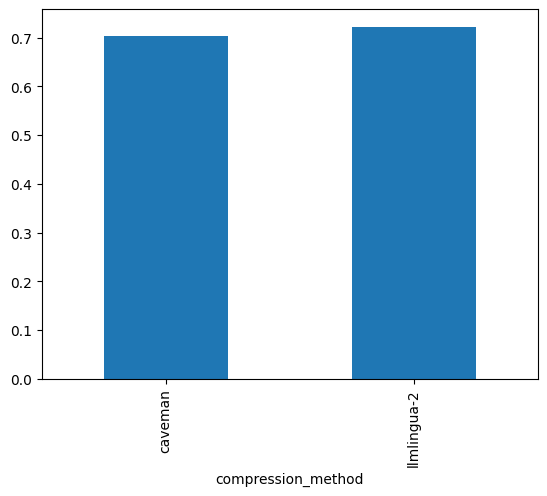

In [44]:
df.groupby('compression_method')['score'].mean().plot.bar(x='compression_method', y='score')

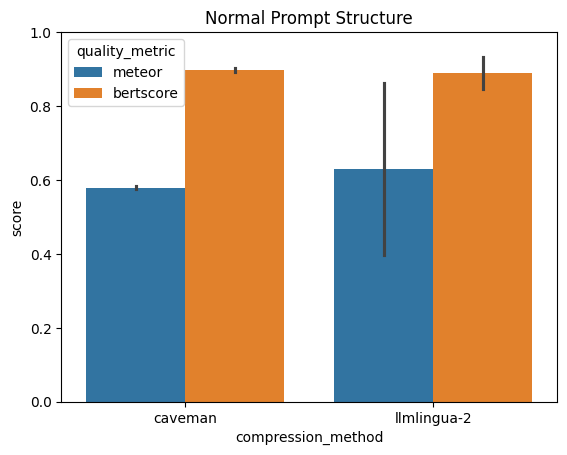

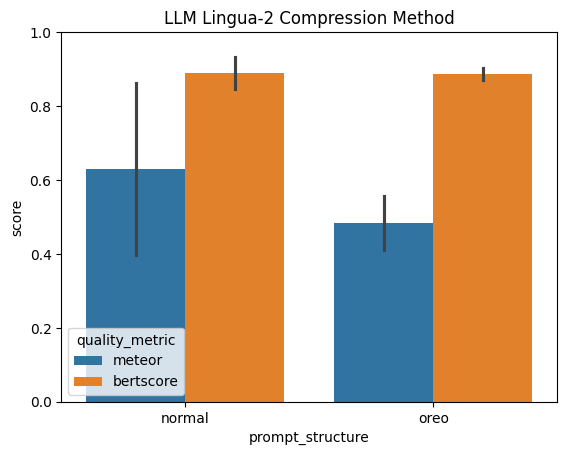

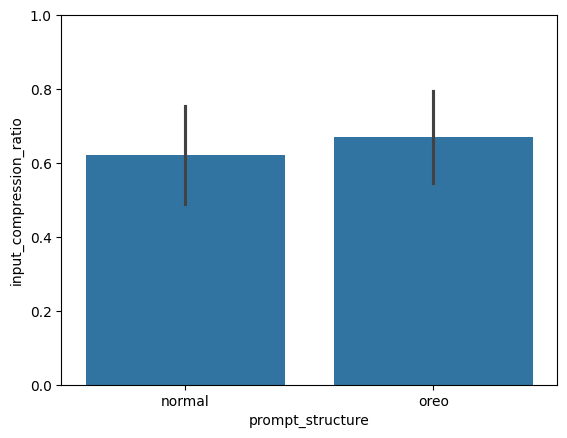

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=df[df['prompt_structure'] == 'normal'], x='compression_method', y='score', hue='quality_metric').set_title('Normal Prompt Structure')
plt.ylim(0,1)
plt.show()

sns.barplot(data=df[df['compression_method'] == 'llmlingua-2'], x='prompt_structure', y='score', hue='quality_metric').set_title('LLM Lingua-2 Compression Method')
plt.ylim(0,1)
plt.show()

sns.barplot(data=df, x='prompt_structure', y='input_compression_ratio')
plt.ylim(0,1)
plt.show()

In [69]:
df.groupby(['prompt_structure', 'compression_method'])['input_compression_ratio'].agg(['mean', 'std'])#.unstack().plot.bar()

mean       std
prompt_structure compression_method                    
normal           caveman             0.806364  0.038675
                 llmlingua-2         0.437296  0.015944
oreo             caveman             0.839931  0.041008
                 llmlingua-2         0.500870  0.015387

<Axes: xlabel='compression_and_structure', ylabel='input_compression_ratio'>

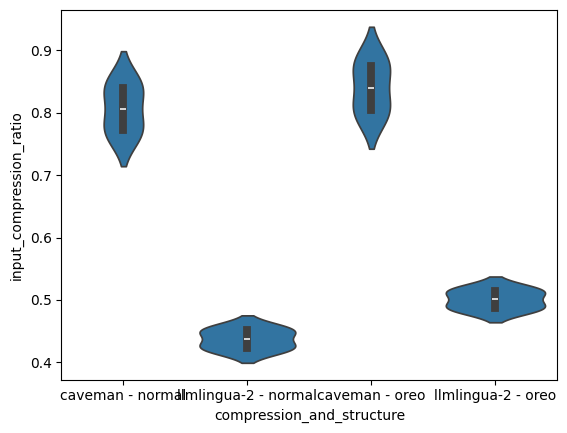

In [70]:
df['compression_and_structure'] = df['compression_method'] + ' - ' + df['prompt_structure']

sns.violinplot(data=df, x='compression_and_structure', y='input_compression_ratio')

<Axes: xlabel='compression_and_structure', ylabel='output_compression_ratio'>

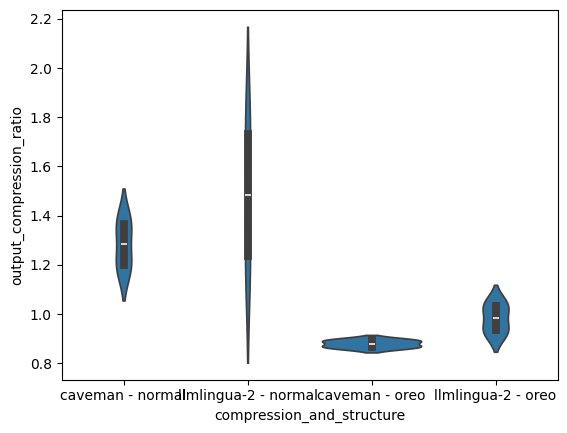

In [71]:
sns.violinplot(data=df, x='compression_and_structure', y='output_compression_ratio')